[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benjamalegni/ML-luka/blob/main/03-nlp-procesamiento-texto/04-analisis-sintactico-semantico/05_NLP_Analisis_Semantico_Discurso_Pragmatica.ipynb)


# Procesamiento de Lenguaje Natural - **Análisis Semántico, Discurso y Pragmática**

Esta notebook presenta ejemplos de los diferentes aspectos relacionados con el análisis semántico, discurso y pragmática.


In [1]:
!pip install sense2vec==2.0.2 pywsd==1.2.5 stanza==1.10.1 ibm-watson==10.0.0 python-dotenv==1.1.0 bert-extractive-summarizer==0.10.1 pysentimiento==0.7.3 textacy==0.13.0 gensim==4.3.3 bertopic==0.17.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 359.4/359.4 kB 14.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 26.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of weasel to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of weasel to determine which version is compatible with other requirements. This could ta

En caso de que los ejemplos lo requieran, los ejecutaremos tomando como base un párrafo de la página de Wikipedia referida a Londres.

In [1]:
text = "London is the capital and largest city of England and of the United Kingdom. \
        Standing on the River Thames in the south-east of England, at the head of its 50-mile (80 km) estuary leading to the North Sea, \
            London has been a major settlement for two millennia.\
        Londinium was founded by the Romans. \
        The City of London, London's ancient core − an area of just 1.12 square miles (2.9 km2) and colloquially known as the Square Mile − retains boundaries that closely follow its medieval limits. \
        The City of Westminster is also an Inner London borough holding city status. Greater London is governed by the Mayor of London and the London Assembly. \
        London is considered to be one of the world's most important global cities and has been termed the world's most powerful, most desirable, most influential, most visited, most expensive, innovative, sustainable, most investment friendly, and most popular for work city. \
        London exerts a considerable impact upon the arts, commerce, education, entertainment, fashion, finance, healthcare, media, professional services, research and development, tourism and transportation. London ranks 26th out of 300 major cities for economic performance. It is one of the largest financial centres and has either the fifth or the sixth largest metropolitan area GDP. \
        It is the most-visited city as measured by international arrivals and has the busiest city airport system as measured by passenger traffic. \
        It is the leading investment destination, hosting more international retailers and ultra high-net-worth individuals than any other city. \
        London's universities form the largest concentration of higher education institutes in Europe, and London is home to highly ranked institutions such as Imperial College London in natural and applied sciences, the London School of Economics in social sciences, and the comprehensive University College London and King's College London. \
        In 2012, London became the first city to have hosted three modern Summer Olympic Games."

text_list = ["London is the capital and largest city of England and of the United Kingdom.",
             "Standing on the River Thames in the south-east of England, at the head of its 50-mile (80 km) estuary leading to the North Sea, London has been a major settlement for two millennia",
            "Londinium was founded by the Romans.",
        "The City of London, London's ancient core − an area of just 1.12 square miles (2.9 km2) and colloquially known as the Square Mile − retains boundaries that closely follow its medieval limits.",
        "The City of Westminster is also an Inner London borough holding city status. Greater London is governed by the Mayor of London and the London Assembly.",
        "London is considered to be one of the world's most important global cities and has been termed the world's most powerful, most desirable, most influential, most visited, most expensive, innovative, sustainable, most investment friendly, and most popular for work city.",
        "London exerts a considerable impact upon the arts, commerce, education, entertainment, fashion, finance, healthcare, media, professional services, research and development, tourism and transportation. London ranks 26th out of 300 major cities for economic performance. It is one of the largest financial centres and has either the fifth or the sixth largest metropolitan area GDP.",
        "It is the most-visited city as measured by international arrivals and has the busiest city airport system as measured by passenger traffic.",
        "It is the leading investment destination, hosting more international retailers and ultra high-net-worth individuals than any other city.",
        "London's universities form the largest concentration of higher education institutes in Europe, and London is home to highly ranked institutions such as Imperial College London in natural and applied sciences, the London School of Economics in social sciences, and the comprehensive University College London and King's College London.",
        "In 2012, London became the first city to have hosted three modern Summer Olympic Games."]

text_short = "London is the capital and largest city of England and of the United Kingdom. \
              Standing on the River Thames in the south-east of England, at the head of its 50-mile (80 km) estuary leading to the North Sea, \
                  London has been a major settlement for two millennia. "


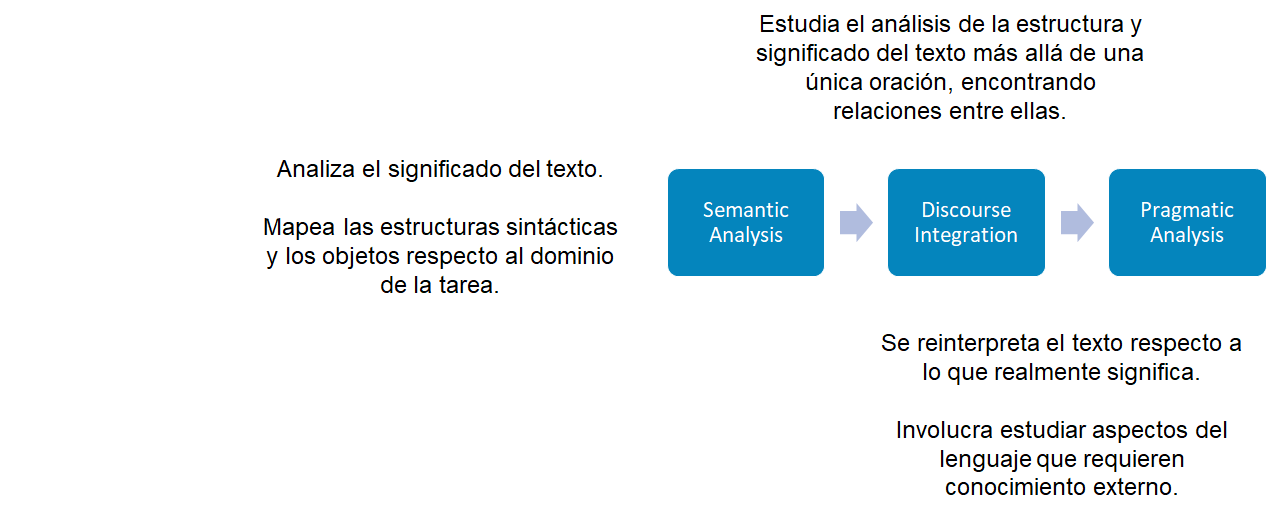

## Análisis Semántico

La semántica describe el proceso de comprender el lenguaje natural. Se ocupa de la determinación de lo que realmente significa una oración al relacionar características sintácticas y desambiguar palabras con múltiples definiciones para el contexto dado.
El significado de las palabras y cómo se combinan para formar el significado de las oraciones.

* Este nivel implica la interpretación apropiada del significado de las oraciones, en lugar del análisis a nivel de palabras o frases individuales.
  * La estructura y el contexto ayudan en la compresión.
  * La estructura básica es la acepción (sense).

* Permite analizar texto en un nivel conceptual opuesto a términos simples.
  * Por ejemplo, durante el proceso de consulta y coincidencia de documentos para la recuperación de información.

* Permite enriquecer textos con el uso de fuentes léxicas.




### Semántica Léxica

Semántica léxica se refiere al análisis del significado de cada una de los items léxicos.
* Palabras.
* Sub-palabras.
* Afijos.
* Palabras compuestas.
* Frases.

* Se trata de la relación entre los items léxico, el siginificado de las oraciones y su sintaxis.
* Cada ítem léxico tiene su propia sintaxis, forma y significado.
* También obtienen significado a partir de las ítems léxicos que los rodean: context, posición

Relaciones entre los ítems léxicos.


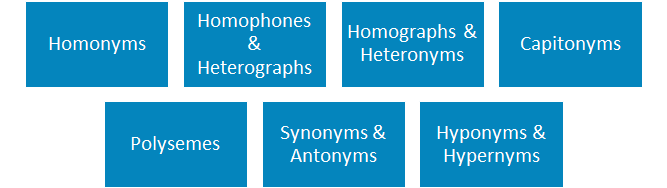

In [2]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
from nltk.corpus import wordnet

syn = wordnet.synsets('bank','n') # syn = wordnet.synsets('talk','v')

for s in syn:
  print("\nSynset name :", s.name())
  print("Abstract term :", s.hypernyms())
  print("Specific term :", s.hyponyms())
  print("Member meronyms :", s.member_meronyms())
  print("Root hypernerm :", s.root_hypernyms())
  print("Lemmas :",s.lemmas())
  for l in s.lemmas():
   if len(l.antonyms()) > 0:
      print(" --",l,l.antonyms())


Synset name : bank.n.01
Abstract term : [Synset('slope.n.01')]
Specific term : [Synset('waterside.n.01'), Synset('riverbank.n.01')]
Member meronyms : []
Root hypernerm : [Synset('entity.n.01')]
Lemmas : [Lemma('bank.n.01.bank')]

Synset name : depository_financial_institution.n.01
Abstract term : [Synset('financial_institution.n.01')]
Specific term : [Synset('agent_bank.n.02'), Synset('lead_bank.n.01'), Synset('home_loan_bank.n.01'), Synset('member_bank.n.01'), Synset('merchant_bank.n.01'), Synset('acquirer.n.02'), Synset('commercial_bank.n.01'), Synset('federal_reserve_bank.n.01'), Synset('credit_union.n.01'), Synset('thrift_institution.n.01'), Synset('state_bank.n.01')]
Member meronyms : []
Root hypernerm : [Synset('entity.n.01')]
Lemmas : [Lemma('depository_financial_institution.n.01.depository_financial_institution'), Lemma('depository_financial_institution.n.01.bank'), Lemma('depository_financial_institution.n.01.banking_concern'), Lemma('depository_financial_institution.n.01.ban

### Word Sense Disambiguation

Las palabras suelen tener más un significado posible.


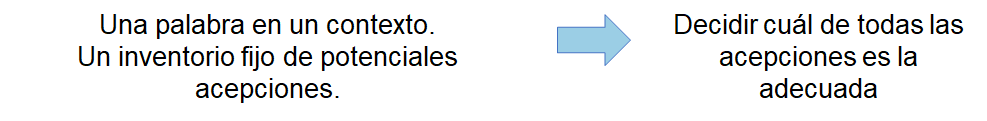

#### NLTK

NLTK se basa en el método de Lesk que mide la superposición entre definiciones de sentido para todas las palabras en contexto.

* Una palabra a la vez.
* Contexto == conjunto de palabras en una oración o párrafo circundante.

Para "mejores" resultados requiere que se le pase el tag de part-of-speech.


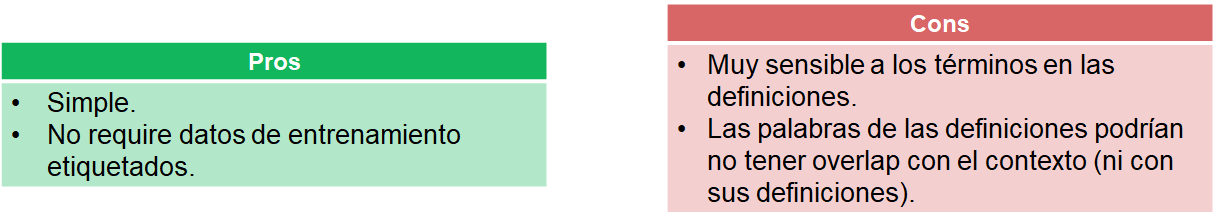

In [4]:
from nltk.wsd import lesk

sent = ["I went to the bank to deposit money"]

print(lesk(sent, 'bank', 'n'))
print(lesk(sent, 'bank','v'))
print(lesk(sent, 'bank'))

Synset('savings_bank.n.02')
Synset('trust.v.01')
Synset('trust.v.01')


In [5]:
from nltk.corpus import wordnet as wn
for ss in wn.synsets('bank'):
    print(ss, ss.definition())

Synset('bank.n.01') sloping land (especially the slope beside a body of water)
Synset('depository_financial_institution.n.01') a financial institution that accepts deposits and channels the money into lending activities
Synset('bank.n.03') a long ridge or pile
Synset('bank.n.04') an arrangement of similar objects in a row or in tiers
Synset('bank.n.05') a supply or stock held in reserve for future use (especially in emergencies)
Synset('bank.n.06') the funds held by a gambling house or the dealer in some gambling games
Synset('bank.n.07') a slope in the turn of a road or track; the outside is higher than the inside in order to reduce the effects of centrifugal force
Synset('savings_bank.n.02') a container (usually with a slot in the top) for keeping money at home
Synset('bank.n.09') a building in which the business of banking transacted
Synset('bank.n.10') a flight maneuver; aircraft tips laterally about its longitudinal axis (especially in turning)
Synset('bank.v.01') tip laterally
Sy

#### [sense2vec](https://github.com/explosion/sense2vec)

* Se basa en word2vec.
* Trata de agregar contextualidad a los embeddings de las palabras, basadas en su desambiguación.
* En lugar de predecir un token dado el contexto, el objetivo es predecir el uso correcto dado el contexto.

* Requiere de corpus etiquetados.
  * Cuenta la cantidad de usos de una palabra, donde cada uso es presentado por una etiqueta.
  * Genera un embedding random para cada uno de los usos.
  * Entrena el modelo usando la arquitectura de word2vec.


In [6]:
# !pip install sense2vec

Para poder usarlo, hay que bajar los modelos pre-entrenados. Hay varias opciones, acá vamos a utilizar los más pequeños (aprox 500 mb).

In [7]:
from tqdm.notebook import tqdm
import io
import os
import requests
import sys

def descargar_archivo(url,datapath): # como vamos a bajar varios archivos, armamos un método
  if os.path.exists(datapath): # antes de descargar el archivo controlamos que no exista
    print('File already exists')
    return

  print("File does not exist")

  req = requests.get(url, stream=True)
  file_size = int(req.headers['Content-Length'])
  chunk_size = 1024  # 1 MB
  num_bars = int(file_size / chunk_size)

  with open(datapath, 'wb') as fp:
    for chunk in tqdm(req.iter_content(chunk_size=chunk_size), total=num_bars, unit='KB', desc=datapath, leave=True, file=sys.stdout):
      fp.write(chunk)

In [8]:
descargar_archivo('https://github.com/explosion/sense2vec/releases/download/v1.0.0/s2v_reddit_2015_md.tar.gz','s2v_reddit_2015_md.tar.gz')

File already exists


In [9]:
import tarfile

tar = tarfile.open("s2v_reddit_2015_md.tar.gz", "r:gz")
tar.extractall()
tar.close()

In [10]:
from sense2vec import Sense2Vec

s2v = Sense2Vec().from_disk("s2v_old")

In [11]:
query = "natural_language_processing|NOUN" # importante respetar la sintaxis que espera los espacios son guiones bajos y hay que pasarle el POS

vector = s2v[query]
print(vector)

[-0.02698926  0.3866803  -0.66829497 -0.41728875  0.26364306 -0.40081096
  0.6281248   0.14720058  0.19218649 -0.0998884   0.26744893 -0.02889291
 -0.17782305 -0.11958034 -0.03006067 -0.24114996 -0.12906119  0.19724639
  0.4380696   0.05275216  0.15804796  0.19498187 -0.08526038 -0.46956626
 -0.11648716  0.07625313 -0.29506105 -0.42849484 -0.40789005 -0.1288717
  0.20095542  0.61653686 -0.05818588 -0.2014371  -0.00563217 -0.5979889
 -0.21555479  0.52637964 -0.23618117 -0.27018833 -0.39888066 -0.03571676
 -0.14596932  0.06775339  0.06443068  0.02549744 -0.03748453 -0.18575297
 -0.2129982   0.5471347   0.05033882 -0.40439808  0.10965174 -0.19026929
 -0.10089809  0.05904212  0.57891583  0.185087   -0.447115    0.09574994
  0.11977117 -0.20688562  0.201603    0.30103895 -0.39587796 -0.58227926
 -0.59210235 -0.34023854 -0.06494252 -0.31400535 -0.05835659 -0.1329348
  0.03754488  0.07223693  0.0788155   0.03512442 -0.16898312 -0.46759027
  0.12015501  0.20531727 -0.25215966  0.11278959  0.14

In [12]:
print(s2v.get_other_senses(query))

['Natural_Language_Processing|ORG']


In [13]:
most_similar = s2v.most_similar(query, n=10)
print(most_similar)

[('machine_learning|NOUN', 0.8987), ('computer_vision|NOUN', 0.8636), ('deep_learning|NOUN', 0.8573), ('data_analysis|NOUN', 0.8352), ('neural_nets|NOUN', 0.8303), ('relational_databases|NOUN', 0.8157), ('algorithms|NOUN', 0.8119), ('neural_networks|NOUN', 0.8041), ('data_processing|NOUN', 0.8034), ('image_recognition|NOUN', 0.8006)]


#### spaCy

No viene por defecto en spaCy, pero se puede agregar el componente de ``sense2vec`` al pipeline.

*Nota*. Pueden aparecer problemas con las versiones de spaCy y sense2vec. Hay una dependencia de la que requieren versiones distintas y al instalar una biblioteca después de la otra, la segunda sobre-escribe la dependencia de la primera. Reinstalar últimas versiones de ambas y debería solucionarse el problema.

*Nota 2*. Si se quiere ejecutar de nuevo la celda donde se crea ``nlp_disam`` dará error de que ``Extension '_s2v' already exists on Doc.``. Para solucionarlo, reiniciar el Runtime y ejecutar nuevamente las celdas.

In [14]:
import spacy
from sense2vec import Sense2VecComponent

In [15]:
# spacy.cli.download('en_core_web_sm')

*Nota*. Si alguna de las celdas siguientes da error de que el ``doc`` ya tiene las extensiones o algo parecido. Reiniciar el runtime y volver a ejecutar.

In [16]:
nlp = spacy.load('en_core_web_sm')
# s2v = Sense2VecComponent(nlp_disam.vocab).from_disk('s2v_old') # si no se setea el vocabulario da error luego al querer acceder a los elementos, esto es para otra versión de spacy
nlp_disam = nlp.add_pipe("sense2vec")
nlp_disam.from_disk('s2v_old')
nlp_disam.vocab = nlp.vocab

In [17]:
doc = nlp("A sentence about natural language processing.")

In [18]:
for ent in doc:
    print("\n",nlp_disam.s2v_key(ent))
    print(ent._.s2v_freq)
    print(ent._.s2v_most_similar(3))


 a|DET
142656038
[(('another', 'DET'), 0.8344), (('an', 'DET'), 0.8261), (('.', 'PUNCT'), 0.8019)]

 sentence|NOUN
127632
[(('sentance', 'NOUN'), 0.9205), (('entire sentence', 'NOUN'), 0.9203), (('whole sentence', 'NOUN'), 0.9094)]

 about|ADP
17240442
[(('abut', 'ADP'), 0.9123), (('talking', 'VERB'), 0.8609), (('about-', 'ADP'), 0.8124)]

 natural|ADJ
129148
[(('unnatural', 'ADJ'), 0.852), (('artificial', 'ADJ'), 0.7718), (('natural thing', 'NOUN'), 0.7384)]

 language|NOUN
242515
[(('langauge', 'NOUN'), 0.912), (('spoken language', 'NOUN'), 0.8985), (('other language', 'NOUN'), 0.8882)]

 processing|NOUN
18567
[(('processing', 'VERB'), 0.8697), (('additional processing', 'NOUN'), 0.8195), (('Processing', 'VERB'), 0.7774)]

 .|PUNCT
350048312
[((',', 'PUNCT'), 0.9312), (('and', 'CONJ'), 0.8561), (('that', 'DET'), 0.851)]


No solamente podemos obtener la información de las palabras individuales, sino que cambién lo podemos hacer por grupos de palabas.

In [19]:
print(doc[3:6])
print(nlp_disam.s2v_key(doc[3:6]))
print(doc[3:6]._.s2v_freq)
print(doc[3:6]._.s2v_vec)
print(doc[3:6]._.s2v_most_similar(5))

natural language processing
natural_language_processing|NOUN
200
[-0.02698926  0.3866803  -0.66829497 -0.41728875  0.26364306 -0.40081096
  0.6281248   0.14720058  0.19218649 -0.0998884   0.26744893 -0.02889291
 -0.17782305 -0.11958034 -0.03006067 -0.24114996 -0.12906119  0.19724639
  0.4380696   0.05275216  0.15804796  0.19498187 -0.08526038 -0.46956626
 -0.11648716  0.07625313 -0.29506105 -0.42849484 -0.40789005 -0.1288717
  0.20095542  0.61653686 -0.05818588 -0.2014371  -0.00563217 -0.5979889
 -0.21555479  0.52637964 -0.23618117 -0.27018833 -0.39888066 -0.03571676
 -0.14596932  0.06775339  0.06443068  0.02549744 -0.03748453 -0.18575297
 -0.2129982   0.5471347   0.05033882 -0.40439808  0.10965174 -0.19026929
 -0.10089809  0.05904212  0.57891583  0.185087   -0.447115    0.09574994
  0.11977117 -0.20688562  0.201603    0.30103895 -0.39587796 -0.58227926
 -0.59210235 -0.34023854 -0.06494252 -0.31400535 -0.05835659 -0.1329348
  0.03754488  0.07223693  0.0788155   0.03512442 -0.16898312 -

#### [pywsd](https://github.com/alvations/pywsd)

Un paquete que integra diferentes alternativas clásicas de desambiguación.


In [20]:
#!pip install -U pywsd

*Nota*. Reiniciar el runtime después de la instalación. Puede suceder que haya conflicto con la versión de ``wn`` que se tenga instalada. En ese caso, ejecutar la siguiente celda.

In [21]:
#!pip install -U wn==0.0.22

In [22]:
import nltk
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
from pywsd.lesk import simple_lesk

sent = 'I went to the bank to deposit my money'
ambiguous = 'bank'
answer = simple_lesk(sent, ambiguous, pos='n') # acá estamos seteando una única palabra a desambiguar

print(answer)
print(answer.definition())

Warming up PyWSD (takes ~10 secs)... 

Synset('depository_financial_institution.n.01')
a financial institution that accepts deposits and channels the money into lending activities


took 11.962515354156494 secs.


Si queremos desambiguar todas las palabras en la oración, podemos hacer:

In [24]:
from pywsd import disambiguate
from pywsd.similarity import max_similarity as maxsim # está basada en las métricas de semejanza semántica que ya vimos.

disambiguation = disambiguate('I went to the bank to deposit my money')
for d in disambiguation:
  print(d)
  if d[1] is not None:
    print("  ",d[1].definition())

('I', None)
('went', Synset('run_low.v.01'))
   to be spent or finished
('to', None)
('the', None)
('bank', Synset('depository_financial_institution.n.01'))
   a financial institution that accepts deposits and channels the money into lending activities
('to', None)
('deposit', Synset('deposit.v.02'))
   put into a bank account
('my', None)
('money', Synset('money.n.03'))
   the official currency issued by a government or national bank


### Named Entity Recognition: Reconocimiento, Identificación o Extracción de Entidades

* Primer paso para la extracción de información.
* Busca identificar y clasificar elementos en el texto en categorías predefinidas como los nombres de:
  * Personas.
  * Organizaciones.
  * Lugares.
  * Expresiones temporales.
  * Cantidades.
  * Valores monetarios, porcentajes.

* NER puede dar respuesta a preguntas cómo:
  * Qué compañías fueron mencionadas en el artículo?
  * Qué productos estaban mencionados en la review?
  * Nombra a alguien el tweet? Incluye la ubicación de alguien?



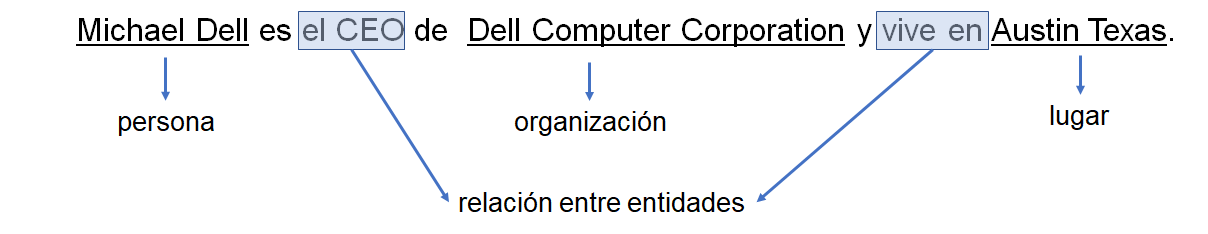

#### NLTK

Como ya vimos en la notebook de Análisis Sintáctico, NLTK incorpora la detección de entidades en el shallow parser.

In [25]:
import nltk
nltk.download('punkt') # tokenizer
nltk.download('averaged_perceptron_tagger') # POS tagger
nltk.download('maxent_ne_chunker') # shallow parsing
nltk.download('words') # lista de palabras, utilizada en spell checker
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


True

In [26]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.chunk import ne_chunk

ne_tree = ne_chunk(pos_tag(word_tokenize(text_short)))

print(ne_tree)

(S
  (GPE London/NNP)
  is/VBZ
  the/DT
  capital/NN
  and/CC
  largest/JJS
  city/NN
  of/IN
  (GPE England/NNP)
  and/CC
  of/IN
  the/DT
  (ORGANIZATION United/NNP Kingdom/NNP)
  ./.
  Standing/VBG
  on/IN
  the/DT
  (ORGANIZATION River/NNP Thames/NNP)
  in/IN
  the/DT
  south-east/NN
  of/IN
  (GPE England/NNP)
  ,/,
  at/IN
  the/DT
  head/NN
  of/IN
  its/PRP$
  50-mile/JJ
  (/(
  80/CD
  km/NN
  )/)
  estuary/JJ
  leading/VBG
  to/TO
  the/DT
  (LOCATION North/NNP Sea/NNP)
  ,/,
  (GPE London/NNP)
  has/VBZ
  been/VBN
  a/DT
  major/JJ
  settlement/NN
  for/IN
  two/CD
  millennia/NN
  ./.)


#### spaCy

Está entrenado con otro corpus distinto al de NLTK.

In [27]:
import spacy
from collections import Counter

In [28]:
nlp = spacy.load('en_core_web_sm')
sentence_nlp = nlp(text_short)

# imprimimos todo lo que encontró
print([(word, word.ent_type_) for word in sentence_nlp if word.ent_type_])

# juntamos las categorías de las entidades que encontró
labels = [x.label_ for x in sentence_nlp.ents]
print(Counter(labels))


[(London, 'GPE'), (England, 'GPE'), (the, 'GPE'), (United, 'GPE'), (Kingdom, 'GPE'), (England, 'GPE'), (50, 'QUANTITY'), (-, 'QUANTITY'), (mile, 'QUANTITY'), (80, 'QUANTITY'), (km, 'QUANTITY'), (the, 'LOC'), (North, 'LOC'), (Sea, 'LOC'), (London, 'GPE'), (two, 'DATE'), (millennia, 'DATE')]
Counter({'GPE': 5, 'QUANTITY': 2, 'LOC': 1, 'DATE': 1})


spaCy también nos deja visualizarlas en el contexto de la oración o texto que analizamos.

In [29]:
from spacy import displacy

displacy.render(sentence_nlp, style='ent', jupyter=True)

#### stanza

Permite acceder de forma directa a las entidades. El componente viene incluido en el pipeline por defecto.

In [30]:
#!pip install stanza

In [31]:
import stanza
stanza.download('en') # la primera vez tenemos que bajar el modelo

INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: en (English) ...


INFO:stanza:Downloaded file to /root/stanza_resources/en/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources


In [32]:
stanza_nlp = stanza.Pipeline(lang='en',processors='tokenize,ner')
stanza_doc = stanza_nlp(text_short)
print(*[f'entity: {ent.text}\ttype: {ent.type}' for ent in stanza_doc.ents], sep='\n')

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: en (English):
| Processor | Package                   |
-----------------------------------------
| tokenize  | combined                  |
| mwt       | combined                  |
| ner       | ontonotes-ww-multi_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


entity: London	type: GPE
entity: England	type: GPE
entity: the United Kingdom	type: GPE
entity: the River Thames	type: LOC
entity: England	type: GPE
entity: 50-mile	type: QUANTITY
entity: 80 km	type: QUANTITY
entity: the North Sea	type: LOC
entity: London	type: GPE
entity: two millennia	type: DATE


#### IBM Watson

Como ya vimos, para poder usar esta biblioteca, se necesita tener una cuenta creada en la [plataforma](https://cloud.ibm.com/registration?target=/developer/watson&cm_sp=WatsonPlatform-WatsonServices-_-OnPageNavLink-IBMWatson_SDKs-_-Python) y a su vez crear una aplicación para el servicio que necesitamos para poder obtener las claves de autentificación.
En este caso vamos a necesitar el de "*Natural Language Understanding*".

*Nota*: En el código no vamos a incluir nada de manejo de errores, pero podría ocurrir que en alguna invocación obtengamos algún error de red, recurso no disponible, queries agotadas, ...

In [33]:
#!pip install --upgrade ibm-watson
#!pip install python-dotenv==1.1.0

In [34]:
from ibm_watson.natural_language_understanding_v1 import Features, EntitiesOptions, KeywordsOptions
from ibm_cloud_sdk_core.authenticators import IAMAuthenticator
import ibm_watson

In [47]:
from dotenv import load_dotenv
import os

# Cargar el archivo .env
load_dotenv()

# Acceder a las variables de entorno
# ibm_api_key = os.getenv('IBM_API_KEY')

from google.colab import userdata
ibm_api_key = userdata.get('IBM_API_KEY')

In [48]:
authenticator = IAMAuthenticator(ibm_api_key)
nlu = ibm_watson.NaturalLanguageUnderstandingV1(version='2018-03-16', authenticator=authenticator)

In [49]:
nlu.analyze(text=text_short,
            features=Features(entities=EntitiesOptions(), keywords=KeywordsOptions())).get_result()

{'usage': {'text_units': 1, 'text_characters': 291, 'features': 2},
 'language': 'en',
 'keywords': [{'text': 'River Thames', 'relevance': 0.943813, 'count': 1},
  {'text': 'head of its 50-mile', 'relevance': 0.783882, 'count': 1},
  {'text': 'largest city of England', 'relevance': 0.760706, 'count': 1},
  {'text': 'south-east of England', 'relevance': 0.680794, 'count': 1},
  {'text': 'major settlement', 'relevance': 0.666118, 'count': 1},
  {'text': 'North Sea', 'relevance': 0.653443, 'count': 1},
  {'text': 'United Kingdom', 'relevance': 0.638679, 'count': 1},
  {'text': 'London', 'relevance': 0.625676, 'count': 2},
  {'text': 'estuary', 'relevance': 0.588309, 'count': 1},
  {'text': 'km', 'relevance': 0.58022, 'count': 1},
  {'text': 'capital', 'relevance': 0.563928, 'count': 1},
  {'text': 'millennia', 'relevance': 0.518114, 'count': 1}],
 'entities': [{'type': 'Location',
   'text': 'south-east of England',
   'relevance': 0.952007,
   'count': 1,
   'confidence': 0.287046},
  {'

### Semantic Role Labeling

Un análisis semántico superficial para representar eventos y sus participantes Parecido al shallow parsing, intenta determinar el rol semántico que cumple cada frase nominal que funciona como argumento de un verbo.

* Para qué sirve?
  * Question Answering.
    * Por ejemplo, permite responder las preguntas “W” (what, where, when, …).
  * Hacer resúmenes y extraer las ideas principales de textos.
  * Hacer representaciones semánticas de los textos en forma de grafos.
  * Comparar traducciones respecto a su contenido y semántica.
  * Puede ayudar en el entrenamiento de chatbots.


Ni NLTK, spaCy o stanza lo proveen de forma directa. Se puede implementar.

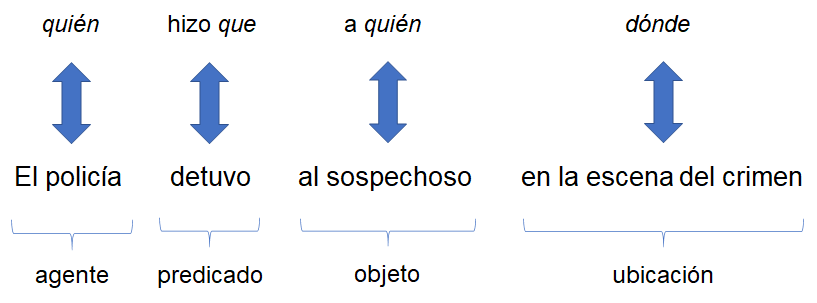

#### IBM Watson

Cambiando las configuraciones de lo que usamos antes, podemos también obtener los roles semánticos.

*Nota*. Recueden que si ya sabemos que nuestra aplicación va a requerir toda la información disponible, es más eficiente en término de cantidad de consultas pedir todo junto.

In [50]:
from ibm_watson.natural_language_understanding_v1 import SemanticRolesOptions

nlu.analyze(text=text_short,
            features=Features(semantic_roles=SemanticRolesOptions())).get_result() # la respuesta va a ser un json que podemos procesar

{'usage': {'text_units': 1, 'text_characters': 291, 'features': 1},
 'semantic_roles': [{'subject': {'text': 'London'},
   'sentence': 'London is the capital and largest city of England and of the United Kingdom.',
   'object': {'text': 'the capital and largest city of England and of the United Kingdom'},
   'action': {'verb': {'text': 'be', 'tense': 'present'},
    'text': 'is',
    'normalized': 'be'}},
  {'subject': {'text': 'on the River Thames'},
   'sentence': 'Standing on the River Thames in the south-east of England, at the head of its 50-mile (80 km) estuary leading to the North Sea,                   London has been a major settlement for two millennia.',
   'object': {'text': 'at the head of its 50-mile (80 km) estuary leading to the North Sea'},
   'action': {'verb': {'text': 'stand', 'tense': 'present participle'},
    'text': 'Standing',
    'normalized': 'stand'}},
  {'subject': {'text': 'London'},
   'sentence': 'Standing on the River Thames in the south-east of England

## Discurso & Pragmática

#### Discurso

Trata del análisis de la estructura y el significado del texto más allá de una sola oración, haciendo conexiones entre palabras y oraciones.

* Involucra la resolución de referencias a elementos anteriores o posteriores en el discurso.
  * Por ejemplo, resolución de pronombres.
  * Uno de los problemas más difíciles. Enfoques recientes se basan en deep learning.


#### Pragmática

El nivel pragmático se ocupa del uso del conocimiento del mundo real y de comprender cómo eso impacta en el significado de lo que se está comunicando.
* Cómo se usa el lenguaje para lograr los objetivos.
* La influencia del contexto (puede incluir hora y lugar) en el significado.

Al analizar la dimensión contextual de los textos y consultas, se obtiene una representación más detallada.

* Este nivel involucra principalmente el procesamiento y la comprensión de las consultas de los usuarios integrando el historial y los objetivos del usuario, así como el contexto en el que se realiza la consulta.

* Facilita la conversación entre el sistema IR y los usuarios.
* Permite obtener el propósito sobre el cual se planea utilizar la información que se busca.



#### Resumen de texto

Realizar un resumen de un texto más largo.

Por qué hacer resúmenes automáticos?
* Los resúmenes reducen el tiempo de lectura.
* Los resúmenes facilitan el proceso de selección de textos.
* El resumen automático mejora la efectividad de la indexación.
* Los algoritmos de resumen automático son menos parciales que los humanos.
* Los resúmenes personalizados son útiles en los sistemas de preguntas y respuestas, ya que proporcionan información personalizada.


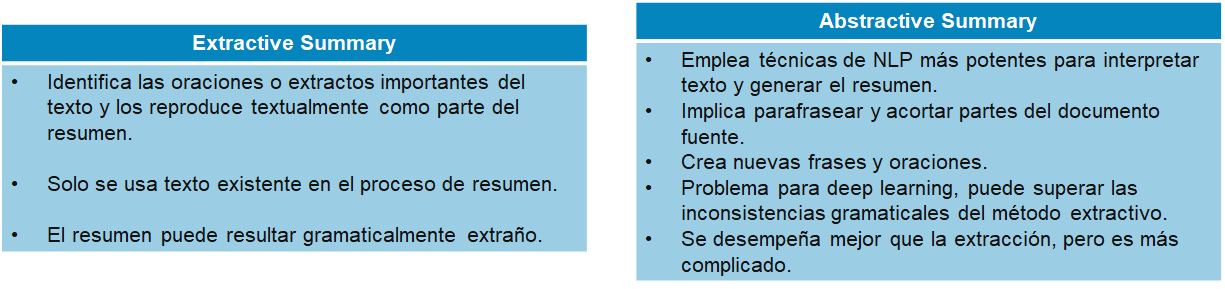

No lo traen las bibliotecas, pero se puede implementar!
Vamos a seguir la siguiente estrategia:

1. Pre-procesar el texto a resumir. En este caso vamos a separar en oraciones y eliminar stopwords.
2. Construir una matriz de semejanza entre las oraciones que componen el texto.
3. Basándonos en la matriz, generar el ranking de oraciones.
4. Elegir las N primeras sentencias para construir el resumen.

Como la técnica funciona considerando como unidad básica las oraciones, el texto a resumir tiene que tener al menos 2 oraciones.

*Nota*. La implementación se basa en NLTK, pero podría basarse en cualquiera de las otras bibliotecas.

In [51]:
from nltk.corpus import stopwords
from nltk.cluster.util import cosine_distance

import re
from collections import Counter

import numpy as np
import pandas as pd

import networkx as nx # la misma biblioteca de grafos de word of graphs

Pre-procesamos el texto, en este caso vamos a implementar una función ad-hoc que retorne un mapa de las oraciones originales y las pre-procesadas.

Por qué mantener ambas versiones? Recordemos que el pre-procesamiento puede ser muy agresivo y que para esta tarea por un lado queremos mantener las oraciones originales y por otro encontrar oraciones que sean semánticamente similares. Entonces, nos quedamos con la referencia a la oración original y también con la versión reducida para luego comparar.

*Nota*. Se podría solo mantener la oración original y luego pre-procesar cada oración cuando se quisiera evaluar su semejanza, pero esto implicar re-pre-procesar oraciones tantas veces como comparaciones quiera hacer.

In [52]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk_stopwords = nltk.corpus.stopwords.words('english')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [53]:
import re
import numpy as np
import pandas as pd
from collections import Counter

def pre_processing(text):
  sentences = {}
  default_st = nltk.sent_tokenize
  sents = default_st(text=text)

  pattern = r'[^a-zA-z0-9\s]'
  default_wt = nltk.word_tokenize

  for x in sents:

    t= re.sub(pattern, '', x)
    words = default_wt(t)

    new_words = [w.lower() for w in words if not w in nltk_stopwords]
    sentences[x] = new_words

  return sentences

Vamos a construir una función para calcular la matriz de semejanzas entre las oraciones.

In [54]:
def sentence_similarity(sent1, sent2):

    all_words = list(set(sent1 + sent2))

    sent1_vals = Counter(sent1)
    sent2_vals = Counter(sent2)

    # convert to word-vectors
    sent1_vect = [sent1_vals.get(word, 0) for word in all_words]
    sent2_vect = [sent2_vals.get(word, 0) for word in all_words]

    return 1 - cosine_distance(sent1_vect, sent2_vect)

def build_similarity_matrix(sentences):
    zero_data = np.zeros(shape=(len(sentences),len(sentences)))
    similarity_matrix = pd.DataFrame(zero_data, columns=sentences.keys(),index=sentences.keys())

    for k1, v1 in sentences.items():
      for k2, v2 in sentences.items():
        if k1 != k2: # ignoramos la diagonal de la matriz
            similarity_matrix[k1][k2] = sentence_similarity(v1, v2)

    return similarity_matrix

Completamos con los pasos que nos faltan!

In [55]:
def generate_summary(text, top_n=3):

  summarize_text = []

  # 1 - Procesamos el texto de entrada
  sentences =  pre_processing(text)

  # 2 - Generamos la matriz de semejanzas entre las oraciones
  sentence_similarity_martix = build_similarity_matrix(sentences)

  # 3 - Construimos el grafo para el pageRank de las oraciones
  sentence_similarity_graph = nx.from_numpy_array(sentence_similarity_martix.to_numpy())
  scores = nx.pagerank(sentence_similarity_graph)

  # 4 - Ordenamos las oraciones de acuerdo a su score
  ranked_sentence = sorted(((scores[i],s) for i,s in enumerate(sentences)), reverse=True)

  summarize_text = [ranked_sentence[i][1] for i in range(top_n)]

  # 5 - Retornamos el resumen
  return " ".join(summarize_text)

In [56]:
generate_summary(text)

'London is the capital and largest city of England and of the United Kingdom. Greater London is governed by the Mayor of London and the London Assembly. The City of Westminster is also an Inner London borough holding city status.'

##### Bert Extractive Summarizer

Basado en [redes neuronales y el modelo BERT](https://pypi.org/project/bert-extractive-summarizer/) de texto.




In [57]:
# !pip install bert-extractive-summarizer

Cuando creemos el ``Summarizer`` va a descargar los modelos necesarios.

In [58]:
from summarizer import Summarizer
model = Summarizer()

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [59]:
result = model(text, min_length=60) # le podemos cambiar la longitud
print(result)

London is the capital and largest city of England and of the United Kingdom. London is considered to be one of the world's most important global cities and has been termed the world's most powerful, most desirable, most influential, most visited, most expensive, innovative, sustainable, most investment friendly, and most popular for work city. It is the most-visited city as measured by international arrivals and has the busiest city airport system as measured by passenger traffic.


#### Extracción de información

La extracción de información es la tarea de extraer automáticamente información estructurada de documentos no estructurados y/o semiestructurados.

Ampliamente utilizado en:
* Question Answering Systems.
* Machine Translation.
* Entity Extraction.
* Event Extraction.
* Verificación de información.


#### spaCy

No lo provee de forma directa, pero es posible instalando una extensión.
El funcionamiento se basa en la construcción del árbol sintáctico y la búsqueda de "caminos" en el árbol donde el sujeto sea el que se pasa por parámetro (en este caso vamos a usar "London") y el verbo es alguna forma del verbo "to be".

In [60]:
# !pip install textacy==0.13.0

In [61]:
import spacy
import textacy.extract

nlp = spacy.load('en_core_web_sm')

london_doc = nlp(text_short)

statements = textacy.extract.semistructured_statements(london_doc,entity='London',cue='be') # en versiones previas no hacía falta definir el cue

for statement in statements:
    print(statement)

SSSTriple(entity=[London], cue=[is], fragment=[the, capital, and, largest, city, of, England])
SSSTriple(entity=[London], cue=[has, been], fragment=[a, major, settlement, for, two, millennia])


La segunda oración que hablaba de dónde se encuentra Londres (sobre el Thames), no la encontró. Vamos a hacer unos pequeños cambios al texto a ver cómo cambiar el resultado.

1. Cambiamos la segunda oración agregando el sujeto "It".
2. Cambiamos la tercera oración "London" por "It".

In [62]:
london_sentence = "London is the capital and largest city of England and of the United Kingdom. It stands on the River Thames in the south-east of England, at the head of its 50-mile (80 km) estuary leading to the North Sea. It has been a major settlement for two millennia."

In [63]:
london_doc = nlp(london_sentence)

statements = textacy.extract.semistructured_statements(london_doc, entity="London",cue='be')

for statement in statements:
    print(statement)

SSSTriple(entity=[London], cue=[is], fragment=[the, capital, and, largest, city, of, England])


#### IBM Watson

No es exactamente lo mismo, pero se podrían utilizar las opciones "concepts", "keywords" (ya la usamos más arriba), o incluso "categories".

In [64]:
from ibm_watson.natural_language_understanding_v1 import ConceptsOptions

nlu.analyze(text=text_short,
            features=Features(concepts=ConceptsOptions())).get_result() # la respuesta va a ser un json que podemos procesar

{'usage': {'text_units': 1, 'text_characters': 291, 'features': 1},
 'language': 'en',
 'concepts': [{'text': 'North Sea',
   'relevance': 0.994658,
   'dbpedia_resource': 'http://dbpedia.org/resource/North_Sea'},
  {'text': 'United Kingdom',
   'relevance': 0.988624,
   'dbpedia_resource': 'http://dbpedia.org/resource/United_Kingdom'},
  {'text': 'River Thames',
   'relevance': 0.980616,
   'dbpedia_resource': 'http://dbpedia.org/resource/River_Thames'},
  {'text': 'England',
   'relevance': 0.94287,
   'dbpedia_resource': 'http://dbpedia.org/resource/England'},
  {'text': 'London',
   'relevance': 0.932055,
   'dbpedia_resource': 'http://dbpedia.org/resource/London'},
  {'text': 'Kilometre',
   'relevance': 0.757322,
   'dbpedia_resource': 'http://dbpedia.org/resource/Kilometre'},
  {'text': 'City Of',
   'relevance': 0.718596,
   'dbpedia_resource': 'http://dbpedia.org/resource/City_Of'},
  {'text': 'Estuary',
   'relevance': 0.516602,
   'dbpedia_resource': 'http://dbpedia.org/reso

### Análisis de Sentimientos

Además de su significado, las palabras también tienen asociadas connotaciones o significados afectivos. Se relaciona con las opiniones, sentimientos o emociones.

Tres dimensiones:

* Valencia. Cuán placentero es un estímulo.
  * +: happy, pleased, satisfied, contented, hopeful
  * -: unhappy, annoyed, unsatisfied, melancholic, despaired, or bored

* Arousal. La intensidad de la emoción provocada por el estímulo.
  * +: stimulated, excited, frenzied, wide-awake, or aroused
  * -: relaxed, calm, sluggish, dull, sleepy, or unaroused

* Dominance. El grado de control ejercido por el estímulo.
  * +: in control, influential, important, dominant, autonomous, or controlling
  * -: controlled, influenced, cared-for, awed, submissive, or guided


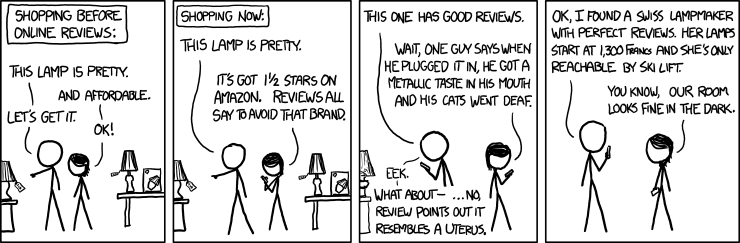

El análisis de sentimientos (también conocido como minería de opinión) intenta identificar y extraer sentimientos  dentro de un texto determinado en blogs, reseñas, redes sociales, foros, noticias, etc.

Los modelos de análisis de sentimientos detectan la polaridad dentro de un texto (por ejemplo, una opinión positiva o negativa), ya sea un texto completo, un párrafo, una oración o una cláusula. Comprender los sentimientos de las personas es esencial para las empresas, ya que los clientes pueden expresar abiertamente sus pensamientos y sentimientos.

Tradicionalmente detección con léxicos o modelos supervisados. (algunos léxicos ya vienen integrados en NLTK)
* VADER lexicon (incluye emojis, dice que fue creado especialmente para social media)
* SentiWordNet (basado en WordNet, asigna un valor de polaridad negativa y postiva a cada synset).
* TextBlob lexicon (también asociado a WordNet).
* AFFIN lexicon (incluye emoticons).

Una de las desventajas del uso de léxicos es que las personas pueden expresan sus emociones de diferentes maneras. Por ejemplo, algunas palabras que típicamente expresan enojo, como “bad” or “kill”, también pueden expresar felicidad.

### Detección de emociones

Tiene como objetivo detectar emociones, como la felicidad, la frustración, la ira, la tristeza, etc. Se suele decir que puede ser la causa de los sentimientos.

También hay léxicos específicos para esta tarea:
* EmoLex (comprende varios léxicos creados tanto manualmente como de forma automática, hashtags). Para cada término le asignan un sentimiento, y dentro de ese sentimiento el nivel de la emoción.
* SentiSense. Asocia sentimiento y emoción a synsets de WordNet y está también disponible en Español.


No todas las bibliotecas lo traen implementado. De todas formas, lo más conveniente sería encontrar un dataset etiquetado y usarlo para entrenar un modelo propio.

#### NLTK

Trae incorporados algunos lexicons para la detección de sentimiento. Vamos a utilizar VADER y SentiWordNet.

##### VADER

Nos va a devolver varios scores. En primer lugar vamos a tener score positivo, negativo y neutro, los cuales representan la proporción del texto que cae en esas categorías. Entre las tres deben sumar 1. Asismismo, se obtiene un score denominado ``compound`` que representa la suma de todos los ratings de las palabras incluidas en el texto, normalizadas entre -1 (negativo extremo) hasta 1 (positivo extremo).

In [65]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [66]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()
for sentence in text_list:
  print(sentence)
  ss = sid.polarity_scores(sentence)
  for k in sorted(ss):
    print('{0}: {1}, '.format(k, ss[k]), end='')

London is the capital and largest city of England and of the United Kingdom.
compound: 0.4215, neg: 0.0, neu: 0.823, pos: 0.177, Standing on the River Thames in the south-east of England, at the head of its 50-mile (80 km) estuary leading to the North Sea, London has been a major settlement for two millennia
compound: 0.0, neg: 0.0, neu: 1.0, pos: 0.0, Londinium was founded by the Romans.
compound: 0.0, neg: 0.0, neu: 1.0, pos: 0.0, The City of London, London's ancient core − an area of just 1.12 square miles (2.9 km2) and colloquially known as the Square Mile − retains boundaries that closely follow its medieval limits.
compound: 0.0, neg: 0.0, neu: 1.0, pos: 0.0, The City of Westminster is also an Inner London borough holding city status. Greater London is governed by the Mayor of London and the London Assembly.
compound: 0.3612, neg: 0.0, neu: 0.909, pos: 0.091, London is considered to be one of the world's most important global cities and has been termed the world's most powerful, 

##### SentiWordNet

Como el nombre lo indica, depende de WordNet y necesita que se indique qué tipo de etiqueta POS tienen los términos.

In [67]:
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('sentiwordnet')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package sentiwordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/sentiwordnet.zip.


True

In [68]:
from nltk.corpus import wordnet as wn
from nltk.corpus import sentiwordnet as swn
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def penn_to_wn(tag):
    """
    Convert between the PennTreebank tags to simple Wordnet tags
    """
    if tag.startswith('J'):
        return wn.ADJ
    elif tag.startswith('N'):
        return wn.NOUN
    elif tag.startswith('R'):
        return wn.ADV
    elif tag.startswith('V'):
        return wn.VERB
    return None

def get_sentiment(word,tag):
    """ returns list of pos neg and objective score. But returns empty list if not present in senti wordnet. """

    wn_tag = penn_to_wn(tag) # si no es de ninguno de estos tres tipos, no se lo analiza
    if wn_tag not in (wn.NOUN, wn.ADJ, wn.ADV, wn.VERB):
        return []

    lemma = lemmatizer.lemmatize(word, pos=wn_tag) # si no existe el lema, se retorna vacío
    if not lemma:
        return []

    synsets = wn.synsets(word, pos=wn_tag) # si no tiene synsets, se retorna vacío
    if not synsets:
        return []

    synset = synsets[0] # acá está desambiguando de la forma más sencilla posible. Se podrían adoptar otras estrategias
    swn_synset = swn.senti_synset(synset.name())

    return [swn_synset.pos_score(),swn_synset.neg_score(),swn_synset.obj_score()]

In [69]:
ps = PorterStemmer()
words_data = ['this','movie','is','wonderful']
# words_data = [ps.stem(x) for x in words_data] # if you want to further stem the word

pos = nltk.pos_tag(words_data)
senti_val = [get_sentiment(x,y) for (x,y) in pos]

print("Etiquetas pos:",pos)
print("Sentimiento de cada una de las palabras:",senti_val)

Etiquetas pos: [('this', 'DT'), ('movie', 'NN'), ('is', 'VBZ'), ('wonderful', 'JJ')]
Sentimiento de cada una de las palabras: [[], [0.0, 0.0, 1.0], [0.25, 0.125, 0.625], [0.75, 0.0, 0.25]]


#### textBlob

Trae un modelo pre-entrenado para la detección de sentimientos. Disponible solo para Inglés y Alemán.

In [70]:
from textblob import TextBlob

In [71]:
sent = TextBlob(text_short)

print(sent.sentiment)
print(sent.sentiment.polarity)

Sentiment(polarity=0.0625, subjectivity=0.5)
0.0625


In [72]:
sent = TextBlob("I am so in love with NLP!")
print(sent.sentiment)
print(sent.sentiment.polarity)

sent = TextBlob("I really hate with NLP!")
print(sent.sentiment)
print(sent.sentiment.polarity)

Sentiment(polarity=0.625, subjectivity=0.6)
0.625
Sentiment(polarity=-1.0, subjectivity=0.9)
-1.0


##### [pysentimiento](https://pypi.org/project/pysentimiento/)

Biblioteca basada en transformers para detección de sentimiento y emociones. Entrenada con español rioplatense.

In [73]:
# !pip install pysentimiento

In [74]:
from pysentimiento import create_analyzer
import transformers

transformers.logging.set_verbosity(transformers.logging.ERROR)

analyzer = create_analyzer(task="sentiment", lang="es")

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [75]:
print(analyzer.predict("Qué gran jugador es Messi"))
print(analyzer.predict("Esto es pésimo"))
print(analyzer.predict("Qué es esto?"))
print(analyzer.predict("Cómo me gusta el procesamiento de lenguaje natural."))

AnalyzerOutput(output=POS, probas={POS: 0.946, NEU: 0.037, NEG: 0.017})
AnalyzerOutput(output=NEG, probas={NEG: 0.887, NEU: 0.098, POS: 0.014})
AnalyzerOutput(output=NEU, probas={NEU: 0.548, NEG: 0.412, POS: 0.041})
AnalyzerOutput(output=POS, probas={POS: 0.947, NEU: 0.047, NEG: 0.005})


In [76]:
analyzer.predict("Me fascina odiar el procesamiento de lenguaje natural.")

AnalyzerOutput(output=NEG, probas={NEG: 0.738, NEU: 0.221, POS: 0.041})

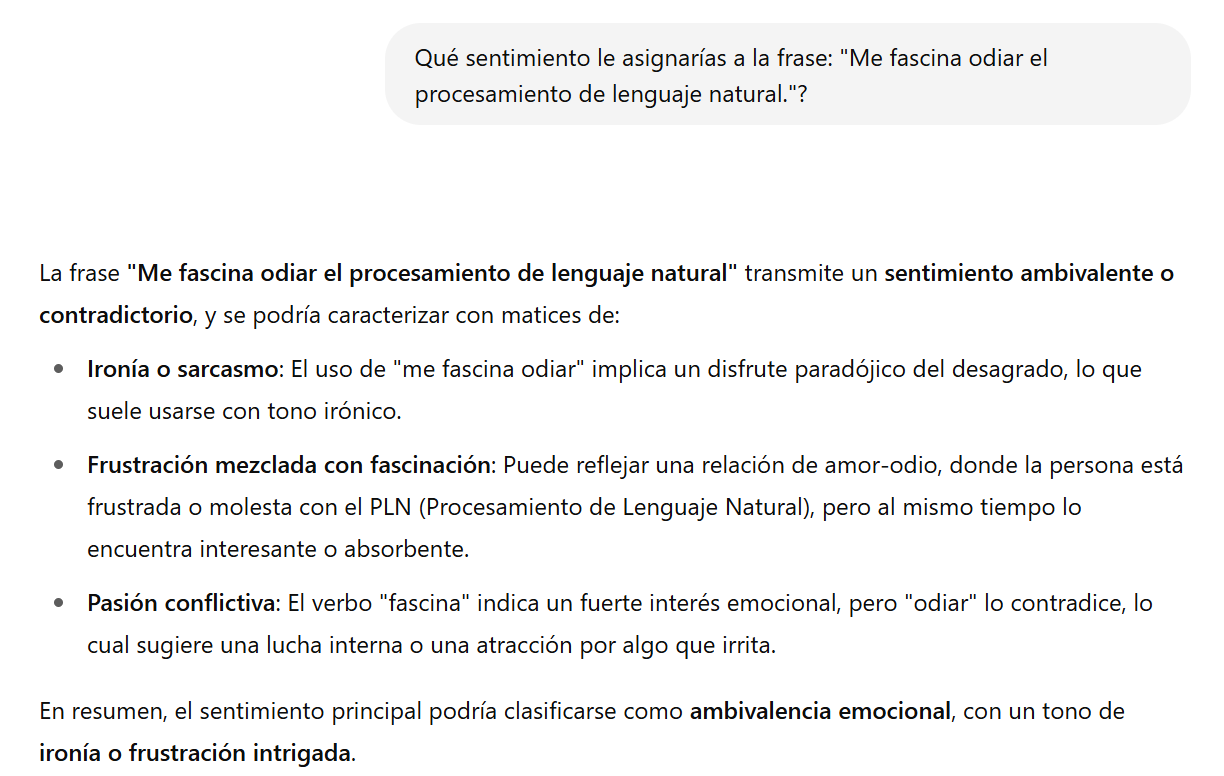

In [77]:
analyzer.predict("Amo odiar el procesamiento de lenguaje natural.")

AnalyzerOutput(output=NEG, probas={NEG: 0.498, NEU: 0.387, POS: 0.115})

In [78]:
analyzer.predict("Odio amar el procesamiento de lenguaje natural.")

AnalyzerOutput(output=NEG, probas={NEG: 0.905, NEU: 0.086, POS: 0.009})

In [79]:
emotion_analyzer = create_analyzer(task="emotion", lang="es")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/435M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [80]:
print(emotion_analyzer.predict("Qué gran jugador es Messi"))
print(emotion_analyzer.predict("Esto es pésimo"))
print(emotion_analyzer.predict("Qué es esto?"))
print(emotion_analyzer.predict("Cómo me gusta el procesamiento de lenguaje natural."))
print(emotion_analyzer.predict("Me encanta!"))

AnalyzerOutput(output=joy, probas={joy: 0.776, others: 0.199, surprise: 0.021, fear: 0.001, disgust: 0.001, sadness: 0.001, anger: 0.001})
AnalyzerOutput(output=others, probas={others: 0.692, surprise: 0.182, sadness: 0.037, anger: 0.027, joy: 0.026, fear: 0.022, disgust: 0.013})
AnalyzerOutput(output=surprise, probas={surprise: 0.640, others: 0.313, joy: 0.025, fear: 0.011, sadness: 0.007, disgust: 0.003, anger: 0.002})
AnalyzerOutput(output=others, probas={others: 0.630, joy: 0.343, surprise: 0.019, fear: 0.004, anger: 0.002, disgust: 0.001, sadness: 0.001})
AnalyzerOutput(output=joy, probas={joy: 0.969, surprise: 0.014, others: 0.011, fear: 0.002, disgust: 0.002, anger: 0.001, sadness: 0.001})


In [81]:
emotion_analyzer.predict("Amo odiar el procesamiento de lenguaje natural.")

AnalyzerOutput(output=others, probas={others: 0.893, joy: 0.046, anger: 0.030, surprise: 0.010, sadness: 0.009, fear: 0.006, disgust: 0.006})

In [82]:
emotion_analyzer.predict("Me fascina odiar el procesamiento de lenguaje natural.")

AnalyzerOutput(output=others, probas={others: 0.916, anger: 0.032, joy: 0.025, sadness: 0.009, disgust: 0.008, surprise: 0.006, fear: 0.004})

#### IBM Watson

Nuevamente, otros parámetros nos permiten obtener los sentimientos y emociones. Se encuentra disponible para idioma Español.

In [83]:
from ibm_watson.natural_language_understanding_v1 import SentimentOptions, EmotionOptions

nlu.analyze(text=text_short,
            features=Features(sentiment=SentimentOptions(),emotion=EmotionOptions())).get_result() # la respuesta va a ser un json que podemos procesar, también tiene una opción para procesarlo con entidades propias de IBM

{'usage': {'text_units': 1, 'text_characters': 291, 'features': 2},
 'sentiment': {'document': {'score': 0, 'label': 'neutral'}},
 'language': 'en',
 'emotion': {'document': {'emotion': {'sadness': 0.130586,
    'joy': 0.681742,
    'fear': 0.079216,
    'disgust': 0.036322,
    'anger': 0.035361}}}}

Si quisieramos, también podríamos obtener el tono de lo escrito. Para esto, necesitamos crear otro recurso en la plataforma de IBM, esta vez el de ``ClassificationsOptions`` y ponerle el modelo correspondiente.

Este servicio no se encuentra disponible para todos los idiomas. Solo para inglés y francés.

NOTA: Esto antes se encontraba disponible en un servicio separado que aceptaba dos modos, uno de texto y otro de conversación, en el cual se realizaba un análizado de ambos participantes del diálogo.

In [84]:
import json
from ibm_watson import NaturalLanguageUnderstandingV1
from ibm_cloud_sdk_core.authenticators import IAMAuthenticator
from ibm_watson.natural_language_understanding_v1 \
    import Features, ClassificationsOptions

authenticator = IAMAuthenticator(ibm_api_key)
natural_language_understanding = NaturalLanguageUnderstandingV1(
    version='2021-08-01',
    authenticator=authenticator
)

natural_language_understanding.set_service_url('https://api.us-south.natural-language-understanding.watson.cloud.ibm.com/instances/25c2f605-ddca-4329-aeca-8456dd6c5c95')

response = natural_language_understanding.analyze(
    text='I am very happy. Are you sure? I do not feel like it',
    features=Features(classifications=ClassificationsOptions(model='tone-classifications-en-v1'))).get_result()

print(json.dumps(response, indent=2))


{
  "usage": {
    "text_units": 1,
    "text_characters": 52,
    "features": 1
  },
  "language": "en",
  "classifications": [
    {
      "class_name": "excited",
      "confidence": 0.525071
    },
    {
      "class_name": "polite",
      "confidence": 0.177783
    },
    {
      "class_name": "satisfied",
      "confidence": 0.176499
    },
    {
      "class_name": "sad",
      "confidence": 0.125818
    },
    {
      "class_name": "sympathetic",
      "confidence": 0.101449
    },
    {
      "class_name": "frustrated",
      "confidence": 0.007278
    },
    {
      "class_name": "impolite",
      "confidence": 0.002382
    }
  ]
}


#### Detección de personalidad

Uno de los modelos más conocidos es el Big 5.



* *Agreeableness - Amabilidad*: cálido, amable, cooperativo, comprensivo, servicial y cortés.
  * Fuerte deseo de obtener aceptación en las relaciones personales como un medio de expresión.
  * Las personas agradables se centran en "llevarse bien", no necesariamente en "salir adelante".

* *Extraversion*: hablador, sociable, apasionado, asertivo, audaz y
dominante
  * Priorizan el deseo de obtener poder e influencia dentro de una sociedad.
  * Posee una gran afectividad positiva, lo que se manifiesta como una tendencia a experimentar placer, estados de ánimo atractivos como entusiasmo, emoción y euforia.

* *Neuroticism - Neurotismo*:
  * Experimenta estados de ánimo desagradables: hostilidad, nerviosismo y molestia.
  * Más probabilidades de evaluar las situaciones cotidianas como estresantes.
  * Es menos probable que crean que pueden hacer frente a los factores estresantes que experimentan.
  * Relacionado con el locus de control (atribuir causas de eventos a sí mismos o al ambiente externo).

*  *Openness	to	Experience - Apertura a la experiencia*:
  * Curioso, imaginativo, creativo, complejo, sofisticado
  * También llamado "curiosidad" o "intelectualidad".
  * Altos niveles de creatividad, la capacidad de generar nuevas y útiles
ideas y soluciones.
  * Las personas altamente abiertas tienen más probabilidades de migrar a actividades artísticas y campos científicos.

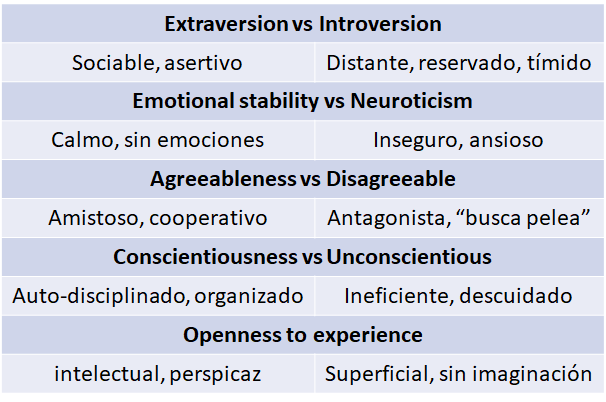

El modelo que se usa en la celda siguiente es [Minej/bert-base-personality](https://huggingface.co/Minej/bert-base-personality), sin embargo, van a ver que los resultados que obtenemos para la misma frase que usan ellos no cumple con el rango que la documentación especifica. Puede que el modelo no sea muy fiable.

In [85]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("Minej/bert-base-personality")
model = AutoModelForSequenceClassification.from_pretrained("Minej/bert-base-personality")

tokenizer_config.json:   0%|          | 0.00/400 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [86]:
text = "I am feeling excited about the upcoming event."

inputs = tokenizer(text, truncation=True, padding=True, return_tensors="pt")
outputs = model(**inputs)
predictions = outputs.logits.squeeze().detach().numpy()

label_names = ['Extroversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']
result = {label_names[i]: predictions[i] for i in range(len(label_names))}

result

{'Extroversion': -0.2255514,
 'Neuroticism': 0.05376943,
 'Agreeableness': 0.029500213,
 'Conscientiousness': -0.45302975,
 'Openness': -0.44577134}

In [87]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

model = AutoModelForSequenceClassification.from_pretrained("KevSun/Personality_LM", ignore_mismatched_sizes=True)
tokenizer = AutoTokenizer.from_pretrained("KevSun/Personality_LM")

config.json:   0%|          | 0.00/995 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [88]:
encoded_input = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=64)

model.eval()  # Set the model to evaluation mode

# Perform the prediction
with torch.no_grad():
    outputs = model(**encoded_input)


predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
predicted_scores = predictions[0].tolist()


trait_names = ["agreeableness", "openness", "conscientiousness", "extraversion", "neuroticism"]


for trait, score in zip(trait_names, predicted_scores):
    print(f"{trait}: {score:.4f}")

agreeableness: 0.2162
openness: 0.1809
conscientiousness: 0.2804
extraversion: 0.1765
neuroticism: 0.1460


### Traducción

La traducción automática es la tarea de convertir automáticamente de un idioma natural a otro, preservando el significado del texto de entrada y produciendo texto fluido en el idioma de salida.

Por qué es difícil?
Orden de las palabras.
Acepciones de las palabras.
Pronombres.
Tiempos verbales.
Idioms.

No hay muchas bibliotecas que lo soporten de forma directa. Sin embargo, siempre es posible entrenar modelos!


### Detección de Tópicos

La detección de tópicos provee modelos para organizar, comprender y resumir (extraer palabras relevantes) grandes cantidades de textos.

Son métodos para encontrar grupos de palabras (los tópicos) dentro de una colección de textos que mejor los representan.

Se basan en que cada texto se puede describir mediante una distribución de tópicos, y cada tópico puede ser descripto por una distribución de palabras.

Métodos tradicionales basados en distribuciones probabilísticas y factorización de matrices.


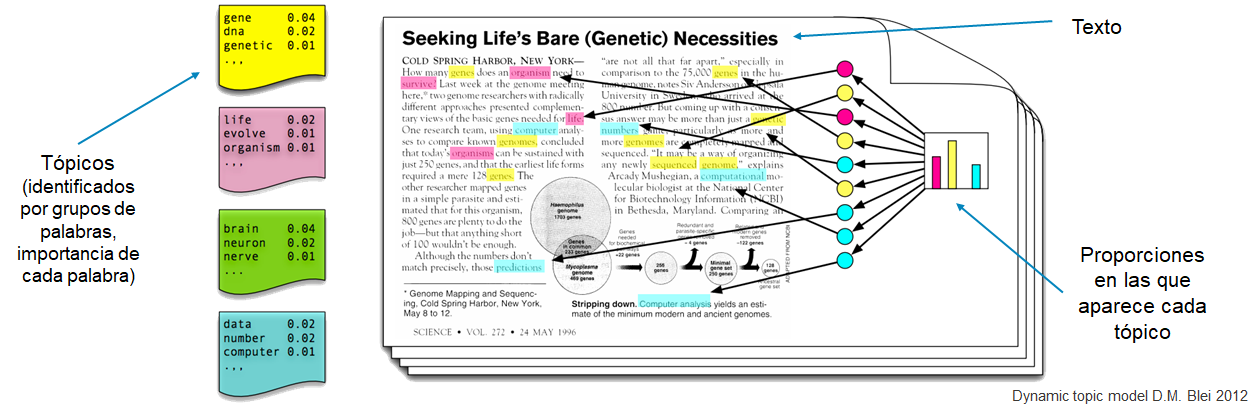

### LDA

* Método basado en distribución de probabilidades.
* No es relevante el orden de las palabras en el texto.
* El número de tópicos a encontrar debe conocerse.
* Una misma palabra puede aparecer en varios tópicos.
* Representa a los textos como una mezcla de tópicos.

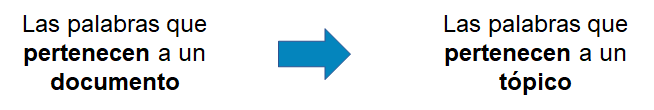

Cómo evaluar los tópicos que encontramos?
* Son interpretables?
* Son únicos/disjuntos?
* Son exhaustivos? Están todos los textos representados?

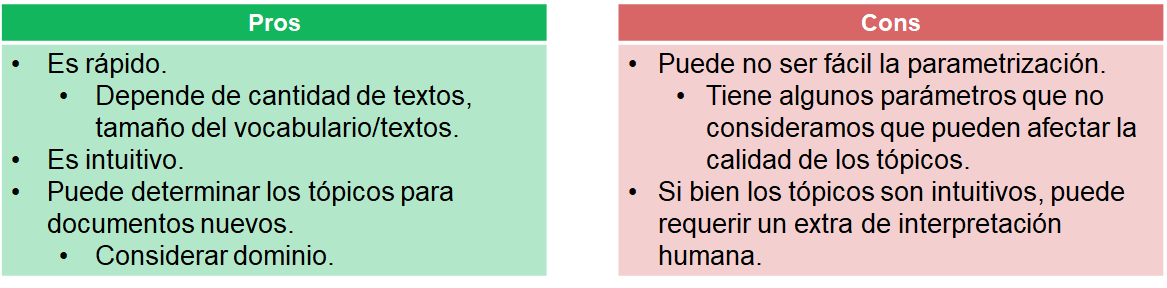

##### Gensim

Como vimos la primer clase, Gensim soporta LDA. Para poder utilizarlo, tenemos que crear el diccionario y el corpus.

In [89]:
# !pip install gensim==4.3.3

In [90]:
import gensim
from gensim import corpora

In [91]:
# El tokenizado depende de nosotros, en este caso estamos haciendo un tokenizado simple basado en los espacios.
texts = [[text for text in doc.split()] for doc in text_list] # acá usamos la lista de oraciones

# usamos GenSimp ara crear el diccionario con los ids únicos.
dictionary = corpora.Dictionary(texts)

print(dictionary)
print(dictionary.token2id)

Dictionary<187 unique tokens: ['England', 'Kingdom.', 'London', 'United', 'and']...>
{'England': 0, 'Kingdom.': 1, 'London': 2, 'United': 3, 'and': 4, 'capital': 5, 'city': 6, 'is': 7, 'largest': 8, 'of': 9, 'the': 10, '(80': 11, '50-mile': 12, 'England,': 13, 'North': 14, 'River': 15, 'Sea,': 16, 'Standing': 17, 'Thames': 18, 'a': 19, 'at': 20, 'been': 21, 'estuary': 22, 'for': 23, 'has': 24, 'head': 25, 'in': 26, 'its': 27, 'km)': 28, 'leading': 29, 'major': 30, 'millennia': 31, 'on': 32, 'settlement': 33, 'south-east': 34, 'to': 35, 'two': 36, 'Londinium': 37, 'Romans.': 38, 'by': 39, 'founded': 40, 'was': 41, '(2.9': 42, '1.12': 43, 'City': 44, "London's": 45, 'London,': 46, 'Mile': 47, 'Square': 48, 'The': 49, 'an': 50, 'ancient': 51, 'area': 52, 'as': 53, 'boundaries': 54, 'closely': 55, 'colloquially': 56, 'core': 57, 'follow': 58, 'just': 59, 'km2)': 60, 'known': 61, 'limits.': 62, 'medieval': 63, 'miles': 64, 'retains': 65, 'square': 66, 'that': 67, '−': 68, 'Assembly.': 69, '

Una vez construido el diccionario, podemos crear la segunda entidad necesaria para usar GenSim, el ``corpus``. Este ``corpus`` es una representación BOW del texto, es decir, una representación que contiene el id del término y la frecuencia en dicho texto.

Para este ejemplo, en lugar de hacer el split nosotros, vamos a usar el ``simple_preprocess`` de GenSim que incluye la tokenización, eliminación de acentos y se queda con los términos que tienen entre 2 y 15 caracteres.

In [92]:
from gensim.utils import simple_preprocess

tokenized_list = [simple_preprocess(doc) for doc in text_list]

dicti = corpora.Dictionary(tokenized_list)
corpus = [dicti.doc2bow(doc, allow_update=True) for doc in tokenized_list]
print(corpus)

[[(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 2), (9, 2), (10, 1)], [(3, 1), (7, 1), (8, 2), (9, 4), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1)], [(9, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1)], [(0, 1), (2, 1), (7, 2), (8, 2), (9, 2), (19, 1), (20, 1), (23, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 2), (56, 1)], [(0, 1), (2, 2), (4, 2), (7, 4), (8, 2), (9, 3), (35, 1), (40, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1)], [(0, 2), (2, 1), (4, 1), (7, 1), (8, 1), (9, 2), (12, 1), (15, 1), (16, 1), (33, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 1), (78, 8), (79, 1), (80, 1), (81, 1), (82

In [93]:
from gensim import models

model_lda = models.LdaModel(corpus=corpus, id2word=dicti, num_topics=4) # pueden probar que pasa si cambian la cantidad de tópicos a analizar

corpus_lda = model_lda[corpus] # aplicando el modelo al mismo corpus con el que lo creamos

# print(model_lda.get_topics())

corpus_lda = model_lda.get_document_topics(corpus)

for doc in corpus_lda:
    print(doc)

[(0, 0.01673161), (1, 0.016889328), (2, 0.016817868), (3, 0.9495612)]
[(3, 0.9769152)]
[(0, 0.035924982), (1, 0.03594795), (2, 0.03594088), (3, 0.8921862)]
[(3, 0.97478074)]
[(3, 0.97201437)]
[(1, 0.98122174)]
[(3, 0.9852726)]
[(0, 0.010457724), (1, 0.010897899), (2, 0.0104749035), (3, 0.96816945)]
[(0, 0.011971912), (1, 0.012072079), (2, 0.011982001), (3, 0.96397406)]
[(3, 0.9845916)]
[(0, 0.016757118), (1, 0.016844837), (2, 0.016755613), (3, 0.9496425)]


In [94]:
from gensim.models import CoherenceModel

# Coherence measures the relative distance between words within a topic.
# Compute Coherence Score --> Acá las definiciones: https://labs.imaginea.com/how-to-measure-topic-coherence/
coherence_model_mass = CoherenceModel(model=model_lda, corpus=corpus, dictionary=dicti, coherence='u_mass')
coherence_model_c_v = CoherenceModel(model=model_lda, texts=tokenized_list, dictionary=dicti, coherence='c_v')

print(coherence_model_mass.get_coherence()) #  a measure how often were the two words (Wi, Wj) were seen together in the corpus. Negativa por cálculo de logaritmos
print(coherence_model_c_v.get_coherence()) # This measure (CV ) combines the indirect cosine measure with the NPMI and the boolean sliding window.

-3.4186195782809374
0.6497882899353471


Una vez que tenemos los tópicos, podemos visualizar los tópicos dominates por documento.

In [95]:
import pandas as pd

def format_topics_sentences(ldamodel, corpus, texts):
    rows = []

    # topics por documentos
    for i, row_list in enumerate(ldamodel[corpus]):
        row = row_list[0] if ldamodel.per_word_topics else row_list
        row = sorted(row, key=lambda x: (x[1]), reverse=True)
        # tópico dominante, contribución, keywords
        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:  # => dominant topic
                wp = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word for word, prop in wp])
                rows.append([int(topic_num), round(prop_topic, 4), topic_keywords])
                break

    # Crear DataFrame desde la lista de filas
    sent_topics_df = pd.DataFrame(rows, columns=['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords'])

    # Agregar el texto original como columna adicional
    contents = pd.Series(texts, name="Text")
    sent_topics_df = pd.concat([sent_topics_df, contents], axis=1)

    return sent_topics_df

# Usar la función
df_topic_sents_keywords = format_topics_sentences(ldamodel=model_lda, corpus=corpus, texts=text_list)

# Formatear resultado final
df_dominant_topic = df_topic_sents_keywords.reset_index()
df_dominant_topic.columns = ['Document_No', 'Dominant_Topic', 'Topic_Perc_Contrib', 'Keywords', 'Text']
df_dominant_topic.head(10)


,Document_No,Dominant_Topic,Topic_Perc_Contrib,Keywords,Text
0,0,3,0.9496,"the, london, and, of, city, is, in, by, as, la...",London is the capital and largest city of Engl...
1,1,3,0.9769,"the, london, and, of, city, is, in, by, as, la...",Standing on the River Thames in the south-east...
2,2,3,0.8922,"the, london, and, of, city, is, in, by, as, la...",Londinium was founded by the Romans.
3,3,3,0.9748,"the, london, and, of, city, is, in, by, as, la...","The City of London, London's ancient core − an..."
4,4,3,0.9720,"the, london, and, of, city, is, in, by, as, la...",The City of Westminster is also an Inner Londo...
5,5,1,0.9812,"most, the, world, and, london, for, has, of, b...",London is considered to be one of the world's ...
6,6,3,0.9853,"the, london, and, of, city, is, in, by, as, la...",London exerts a considerable impact upon the a...
7,7,3,0.9682,"the, london, and, of, city, is, in, by, as, la...",It is the most-visited city as measured by int...
8,8,3,0.9640,"the, london, and, of, city, is, in, by, as, la...","It is the leading investment destination, host..."
9,9,3,0.9846,"the, london, and, of, city, is, in, by, as, la...",London's universities form the largest concent...


Nubes de palabras de keywords por tópico:

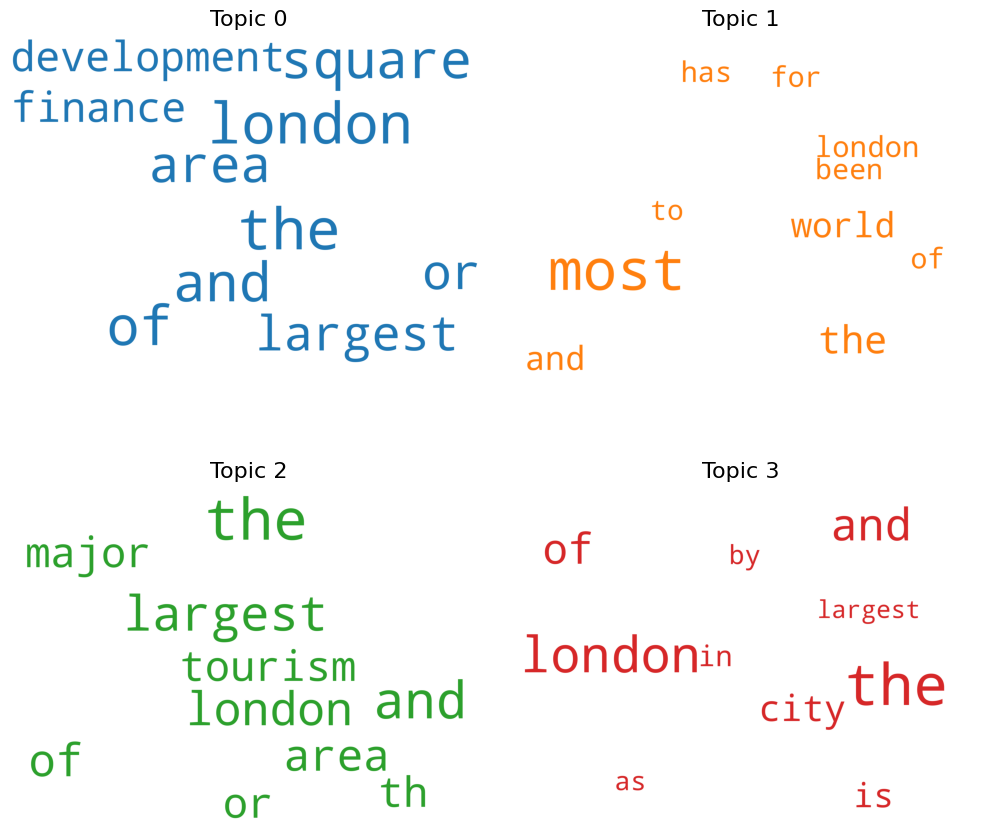

In [96]:
from matplotlib import pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import matplotlib.colors as mcolors

cols = [color for name, color in mcolors.TABLEAU_COLORS.items()]  # more colors: 'mcolors.XKCD_COLORS'

cloud = WordCloud(stopwords=STOPWORDS,
                  background_color='white',
                  width=2500,
                  height=1800,
                  max_words=10,
                  colormap='tab10',
                  color_func=lambda *args, **kwargs: cols[i],
                  prefer_horizontal=1.0)

topics = model_lda.show_topics(formatted=False)

fig, axes = plt.subplots(2, 2, figsize=(10,10), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)
    topic_words = dict(topics[i][1])
    cloud.generate_from_frequencies(topic_words, max_font_size=300)
    plt.gca().imshow(cloud)
    plt.gca().set_title('Topic ' + str(i), fontdict=dict(size=16))
    plt.gca().axis('off')


plt.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()

Ahí calculamos para un único modelo. Ahora vamos a generarnos los valores para varias cantidades de tópicos.

*Nota*. Solo estamos configurando la cantidad de tópicos, recordemos que hay más parámetros para configurar.

*Nota 2*. Por más que subamos la cantidad de iteraciones es muy probable que no converga dado que le dimos pocos textos.

In [97]:
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = gensim.models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=2, iterations=50)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=tokenized_list, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

Vamos a generar nuestro modelo para diferentes cantidades de tópicos.

In [98]:
start = 2
limit = 10
step = 1
model_list, coherence_values = compute_coherence_values(dictionary=dicti, corpus=corpus, texts=tokenized_list, start=start, limit=limit, step=step)

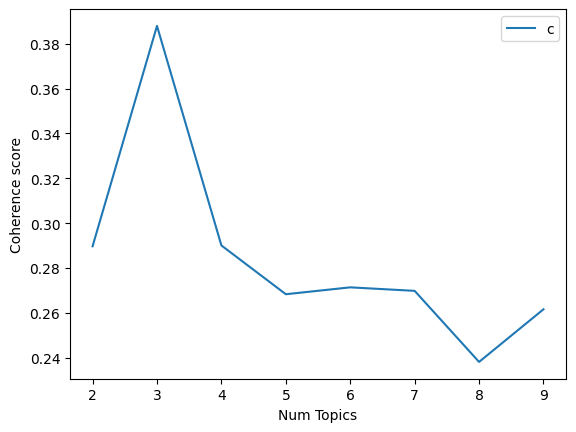

In [99]:
# veamos el codo
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [100]:
# imprimir la coherencia
for m, cv in zip(x, coherence_values):
    print("Num Topics =", m, " has Coherence Value of", round(cv, 4))

# seleccionar un modelo e imprimir
optimal_model = model_list[2]
model_topics = optimal_model.show_topics(formatted=False)
print(optimal_model.print_topics(num_words=10))

Num Topics = 2  has Coherence Value of 0.2897
Num Topics = 3  has Coherence Value of 0.388
Num Topics = 4  has Coherence Value of 0.2901
Num Topics = 5  has Coherence Value of 0.2683
Num Topics = 6  has Coherence Value of 0.2714
Num Topics = 7  has Coherence Value of 0.2698
Num Topics = 8  has Coherence Value of 0.2381
Num Topics = 9  has Coherence Value of 0.2616
[(0, '0.068*"the" + 0.035*"london" + 0.030*"of" + 0.024*"and" + 0.014*"is" + 0.012*"city" + 0.012*"in" + 0.012*"has" + 0.011*"by" + 0.010*"leading"'), (1, '0.045*"london" + 0.043*"the" + 0.042*"and" + 0.036*"most" + 0.029*"city" + 0.029*"of" + 0.024*"is" + 0.015*"as" + 0.014*"in" + 0.012*"college"')]


Otra opción para hacer LDA con sklearn.

In [101]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer='word',
                             lowercase=True,                   # convert all words to lowercase
                            )

data_vectorized = vectorizer.fit_transform(text_list)

In [102]:
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(n_components=20,               # Number of topics
                                      max_iter=10,               # Max learning iterations
                                      learning_method='online',
                                      random_state=100,          # Random state
                                      batch_size=128,            # n docs in each learning iter
                                     )
lda_output = lda_model.fit_transform(data_vectorized)

print(lda_model)  # Model attributes

LatentDirichletAllocation(learning_method='online', n_components=20,
                          random_state=100)


In [103]:
# Log Likelyhood: Higher the better
print("Log Likelihood: ", lda_model.score(data_vectorized))

# Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
# perplexity puede no ser la mejor, dado que no considera el contexto ni la semántica de las palabras
print("Perplexity: ", lda_model.perplexity(data_vectorized))

# See model parameters
print(lda_model.get_params())

Log Likelihood:  -4073.6965233139986
Perplexity:  531513.5095495104
{'batch_size': 128, 'doc_topic_prior': None, 'evaluate_every': -1, 'learning_decay': 0.7, 'learning_method': 'online', 'learning_offset': 10.0, 'max_doc_update_iter': 100, 'max_iter': 10, 'mean_change_tol': 0.001, 'n_components': 20, 'n_jobs': None, 'perp_tol': 0.1, 'random_state': 100, 'topic_word_prior': None, 'total_samples': 1000000.0, 'verbose': 0}


### Latent Semantic Analysis (LSA)

* La idea es representar los textos en una menor dimensión, obtenidas mediante la factorización de matrices.
* Se basa en la idea de que las palabras aparecerán en textos que muestran algún rasgo de semejanza, si tienen un significado parecido.
* Requiere definir el número K de tópicos (dimension de la matriz).


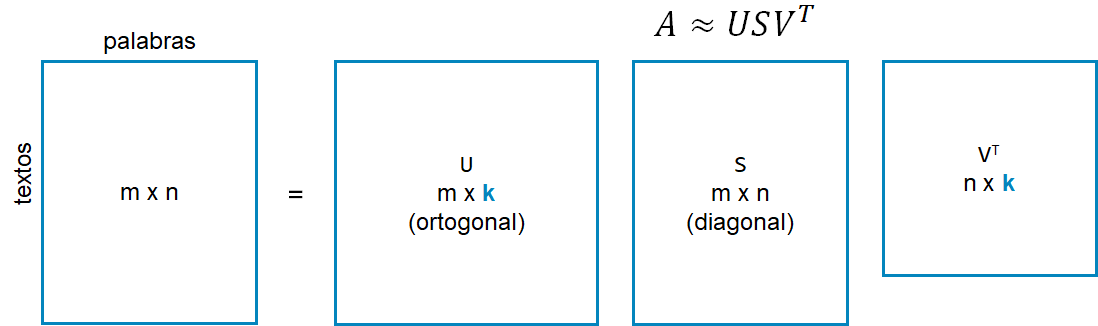

* Puede no ser fácil elegir K.
* Las representaciones no son intuitivas como en LDA.
  * No sabemos cuáles son los tópicos.
  * Los valores en los vectores son arbitrarios.
* Se requirere de una gran cantidad de textos.
* Una representación no del todo eficiente.
* No tán rápido como LDA.
* Puede no capturar completamente las relaciones de sinonimia.


##### Sklearn

Mediante la transformación SVD truncada permite obtener la representación LSA.

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.pipeline import Pipeline

vectorizer = TfidfVectorizer(stop_words='english',
                             use_idf=True,
                             smooth_idf=True)

svd_model = TruncatedSVD(n_components=10,
                         algorithm='randomized',
                         n_iter=10)

#Pipe tf-idf and SVD, apply on our input documents
svd_transformer = Pipeline([('tfidf', vectorizer), ('svd', svd_model)])

svd_matrix = svd_transformer.fit_transform(text_list)

print(svd_matrix)

[[ 5.33941651e-01 -9.25320008e-02  2.05972209e-01 -1.91326027e-17
   5.99325878e-02 -3.53978801e-01  1.58082339e-01 -1.47884516e-01
   3.06265289e-01  6.05030608e-01]
 [ 2.75886802e-01 -7.02229932e-02  7.42201695e-01 -1.42490411e-14
  -3.08516771e-01 -2.12434931e-02 -3.42407775e-01 -1.42103575e-01
   1.55510394e-01 -3.31462444e-01]
 [ 1.91433800e-16  9.64447898e-16 -4.41553138e-16  1.00000000e+00
  -2.83821920e-14 -4.35967181e-15 -1.03997039e-14 -2.05465388e-14
  -4.50585859e-15  5.82950862e-17]
 [ 3.83783285e-01 -1.05191063e-01 -5.94746464e-03 -7.44935995e-15
  -3.32512025e-01  7.67006945e-01  2.52051606e-01 -1.66286069e-01
  -1.04884730e-01  1.52252094e-01]
 [ 6.30129775e-01 -5.04068854e-02 -2.46322190e-01  2.50183624e-15
  -1.14207959e-01  3.47094086e-03 -3.75782339e-02  2.48129470e-01
   1.57649736e-01 -1.09789088e-02]
 [ 2.84921082e-01  3.80110386e-01 -9.88891177e-02  7.80134806e-15
   5.44856639e-01  3.26570194e-01 -5.51221802e-01 -1.73010866e-01
   1.35743582e-01  7.39823281e-02

#### [bertopic]()

In [105]:
# !pip install bertopic==0.17.0

In [106]:
# Paso 1: Cargar datos
from sklearn.datasets import fetch_20newsgroups

# Usamos un subconjunto del dataset 20 Newsgroups
docs = fetch_20newsgroups(subset='all', categories=['sci.space', 'rec.autos', 'talk.politics.misc']).data[:1000]

# Paso 2: Crear modelo BERTopic
from bertopic import BERTopic
topic_model = BERTopic(language="english", verbose=True, calculate_probabilities=True)

# Paso 3: Entrenar el modelo
topics, probs = topic_model.fit_transform(docs)

# Paso 4: Ver los tópicos más relevantes
print("\nTop 5 tópicos:")
print(topic_model.get_topic_info().head())

# Paso 5: Ver las palabras clave de un tópico específico
print("\nPalabras clave del tópico 1:")
print(topic_model.get_topic(1))

2026-06-30 18:11:15,101 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2026-06-30 18:13:40,355 - BERTopic - Embedding - Completed ✓
2026-06-30 18:13:40,357 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 18:13:54,130 - BERTopic - Dimensionality - Completed ✓
2026-06-30 18:13:54,131 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 18:13:54,252 - BERTopic - Cluster - Completed ✓
2026-06-30 18:13:54,262 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 18:13:54,653 - BERTopic - Representation - Completed ✓



Top 5 tópicos:
   Topic  Count               Name  \
0     -1     59  -1_the_in_car_and   
1      0    388    0_the_of_to_and   
2      1    261   1_the_to_of_that   
3      2    159   2_the_car_and_in   
4      3     28     3_v6_v4_v8_v12   

                                      Representation  \
0     [the, in, car, and, to, of, it, you, is, from]   
1  [the, of, to, and, in, is, for, that, space, f...   
2    [the, to, of, that, and, in, is, you, it, have]   
3     [the, car, and, in, is, to, it, of, for, that]   
4    [v6, v4, v8, v12, the, in, blah, vx, eliot, re]   

                                 Representative_Docs  
0  [From: mark@wdcwdc.sps.mot.com (Mark Shaw)\nSu...  
1  [From: hathaway@stsci.edu\nSubject: Re: Vandal...  
2  [From: Clinton-HQ@Campaign92.Org (Clinton/Gore...  
3  [From: oaddab@stdvax (DIRK BROER)\nSubject: Re...  
4  [From: aas7@po.CWRU.Edu (Andrew A. Spencer)\nS...  

Palabras clave del tópico 1:
[('the', 0.0551454943838996), ('to', 0.04653964860058709),

In [107]:
# Visualización general de tópicos
topic_model.visualize_topics()

In [108]:
# Visualización de términos clave en un tópico específico
topic_model.visualize_barchart(top_n_topics=5)

In [109]:
# Visualización de distribución de tópicos por documento
topic_model.visualize_distribution(probs[0], min_probability=0.01)

In [110]:
# Visualización jerárquica (dendrograma de tópicos)
topic_model.visualize_hierarchy()

In [111]:
# Visualización de similitud entre tópicos
topic_model.visualize_heatmap()

#### El modelo ```T5``` y su utilidad para múltiples tareas

In [112]:
import torch
from transformers import AutoTokenizer, AutoModelWithLMHead

tokenizer=AutoTokenizer.from_pretrained('T5-base')
model=AutoModelWithLMHead.from_pretrained('T5-base', return_dict=True)

config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [113]:
input_text = "The T5 model is based on the transformer architecture and is used for many natural language processing tasks like translation, summarization, question answering, and more. It was trained using a multi-task learning objective, and treats all NLP tasks as a text-to-text problem."

# Texto para resumir
input_text_summary = "summarize: " + input_text

# Tokenizamos el texto
inputs = tokenizer.encode(input_text_summary, return_tensors="pt", truncation=True, max_length=512)

# Generamos el resumen
outputs = model.generate(inputs)

# Decodificamos el resumen generado
summary_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(f"Resumen: {summary_text}")

Resumen: the T5 model is used for many natural language processing tasks . it treats all NLP tasks


In [114]:
# Texto de ejemplo (en inglés)
input_text = "Translate English to Spanish: How are you?"

# Tokenizamos el texto
inputs = tokenizer.encode(input_text, return_tensors="pt")

# Generamos la traducción
outputs = model.generate(inputs)

# Decodificamos el texto generado
translated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(f"Texto traducido: {translated_text}")

Texto traducido: Wie sind Sie?
